# BUCSS 2026
## AI Session Hands-On Part 2: Training different models

In this notebook you will:
- Load the training data
- Train AI models
- Test on different data sets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#These are internal
from scripts.splitting_and_training import split_data, train_model, feature_selection
from scripts.plotting import obs_map


First we need to decide if we want every column in our dataframe as a feature in our ML model. 

In [2]:
df = pd.read_parquet("../dataframes_for_training/dortmund_training.parquet")

hod = df["datetime_utc"].dt.hour
doy = df["datetime_utc"].dt.dayofyear
df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

df.columns

Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000',
       'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500',
       'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'lcz_nearest', 'LCZ_1',
       'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9',
       'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16',
       'LCZ_17', 't2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac',
       'tp_deac', 'rh', 'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin',
       'doy_cos'],
      dtype='object')

### 1. Select the target variable

In [3]:
df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]

target = "temp_diff"  # "air_temperature"

target_col = df[target]  




### 2. Split the data into training and validation sets

In [4]:
# drop any possible target variable from the training dataframe (X)
X = df.drop(columns=["temp_diff", "air_temperature"]).copy()

# Set y as the target column
y = target_col

# Check split_data function to see the different types
mode = "block_spatial" # "random", "random_spatial", "block_spatial"

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = split_data(X, y, mode) 



### 3. Feature selection

In [15]:
MODEL_TYPE = "xgboost" # "xgboost", "randomforest", "lur"

# Check feature_selection function
features = feature_selection(MODEL_TYPE, X_train, y_train, X_val, y_val)

# We subset our predictor tables by only keeping the selected features
X_train_sel = X_train[features]
X_val_sel   = X_val[features]

['latitude', 'longitude', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250', 'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50', 'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000', 'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500', 'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'LCZ_1', 'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9', 'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16', 'LCZ_17', 'sp', 'ssrd_deac', 'tp_deac', 'rh', 'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin', 'doy_cos']


### 4. Scaling (?)

This part could also take place before the feature selection since the feature selection for LUR fits mini models...

In [16]:
SCALE = True

# Save unscaled ERA5-Land input bc it's needed for error metrics
t2m_corr = X_val["t2m_corr"]

if SCALE:
    # scale all predicors except for the temporal predictors (already -1 to 1)
    cyclical = {"tod_sin", "tod_cos", "doy_sin", "doy_cos"}

    # select the predictors to be scaled
    scale_cols = [c for c in X_train_sel.columns if c not in cyclical]

    # use sklearn's StandardScaler: scales by sample mean and variance
    scaler = StandardScaler()
    
    X_train_sel = X_train_sel.copy()
    X_val_sel = X_val_sel.copy()

    # fit the mean and variance from the training data, scale the training data
    X_train_sel[scale_cols]  = scaler.fit_transform(X_train_sel[scale_cols])   

    # apply the training fit to scale the validation data
    X_val_sel[scale_cols] = scaler.transform(X_val_sel[scale_cols])      

### 5. Model training / fitting

In [17]:
# see train_model function
y_pred, model = train_model(X_train_sel, X_val_sel, y_train, y_val, model_type = MODEL_TYPE)

[0]	train-rmse:1.41322	valid-rmse:1.41936
[15]	train-rmse:0.99869	valid-rmse:1.14421
[30]	train-rmse:0.86281	valid-rmse:1.04348
[45]	train-rmse:0.80304	valid-rmse:0.99561
[60]	train-rmse:0.75042	valid-rmse:0.96169
[75]	train-rmse:0.69700	valid-rmse:0.92742
[90]	train-rmse:0.65285	valid-rmse:0.90006
[105]	train-rmse:0.62565	valid-rmse:0.88077
[120]	train-rmse:0.60140	valid-rmse:0.86667
[135]	train-rmse:0.58162	valid-rmse:0.85847
[150]	train-rmse:0.56182	valid-rmse:0.84748
[165]	train-rmse:0.54456	valid-rmse:0.83749
[180]	train-rmse:0.52970	valid-rmse:0.82735
[195]	train-rmse:0.51622	valid-rmse:0.82066
[210]	train-rmse:0.50295	valid-rmse:0.81433
[225]	train-rmse:0.48998	valid-rmse:0.80759
[240]	train-rmse:0.48083	valid-rmse:0.80223
[255]	train-rmse:0.47150	valid-rmse:0.79834
[270]	train-rmse:0.46259	valid-rmse:0.79455
[285]	train-rmse:0.45537	valid-rmse:0.79094
[300]	train-rmse:0.44730	valid-rmse:0.78773
[315]	train-rmse:0.43984	valid-rmse:0.78580
[330]	train-rmse:0.43438	valid-rmse:0.78

### 6. Error metrics

In [18]:
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

# we ensure the metrics are valid for both targets
add_back = t2m_corr.values if target == "temp_diff" else 0

y_obs = y_val.values + add_back
y_model = y_pred + add_back

rmse = root_mean_squared_error(y_obs, y_model)
r2 = r2_score(y_obs, y_model)
bias = np.mean(y_model - y_obs)


print(f"{MODEL_TYPE} Validation RMSE: {rmse:.2f} °C   R²: {r2:.2f}   Bias: {bias:.2f} °C")

# # baseline: ERA5-corrected alone vs observed
# rmse_era5 = np.sqrt(mean_squared_error(y_rec, t2m_corr.values))
# r2_era5   = r2_score(y_rec, t2m_corr.values)
# print(f"ERA5 RMSE: {rmse_era5:.3f} °C   R²: {r2_era5:.3f}")


xgboost Validation RMSE: 0.76 °C   R²: 0.99   Bias: -0.04 °C


In [21]:
def predict_on_all_stations(target, model, df, model_type,
                            features, scaler=None, scale_cols=None):
    Xf = df[features].copy()

    # apply the SAME train-fit scaling (LUR needs it; XGBoost is scale-invariant but harmless)
    if scaler is not None and scale_cols is not None:
        cols = [c for c in scale_cols if c in Xf.columns]
        Xf[cols] = scaler.transform(Xf[cols])          # transform, NOT fit_transform

    if model_type == "xgboost":
        dall = xgb.DMatrix(Xf, feature_names=features)
        pred = model.predict(dall)

    elif model_type == "lur":
        Xall = sm.add_constant(Xf, has_constant="add")
        pred = model.predict(Xall)

    return pd.Series(
        pred + df["t2m_corr"].values if target == "temp_diff" else pred,
        index=df.index)

features = list(X_train_sel.columns)      # the SELECTED features, same as model used
all_preds = predict_on_all_stations(target, model, df, MODEL_TYPE,
                                    features=features,
                                    scaler=scaler if SCALE else None,
                                    scale_cols=scale_cols if SCALE else None)

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error

def per_station_table(df, all_preds, y_val_index, target, split="all"):
    """Per-station RMSE (model vs ERA5) with LCZ and split flag.
       split: 'all', 'val', or 'train'."""
    val_ids = set(df.loc[y_val_index, "station_id"].unique())

    # reconstruct observed + model absolute temperature for ALL rows
    add_back = df["t2m_corr"].values if target == "temp_diff" else 0
    tbl = pd.DataFrame({
        "station_id": df["station_id"].values,
        "LCZ":        df["lcz_nearest"].values.astype(int),
        "obs":        df["air_temperature"].values,
        "model":      all_preds.loc[df.index].values,       # index-aligned
        "era5":       df["t2m_corr"].values,
    }, index=df.index).dropna(subset=["obs", "model", "era5"])

    tbl["split"] = np.where(tbl["station_id"].isin(val_ids), "val", "train")

    if split != "all":
        tbl = tbl[tbl["split"] == split]

    out = (tbl.groupby(["station_id", "LCZ", "split"])
              .apply(lambda g: pd.Series({
                  "model_rmse": root_mean_squared_error(g["obs"], g["model"]),
                  "era5_rmse":  root_mean_squared_error(g["obs"], g["era5"]),
              }), include_groups=False)
              .reset_index())
    out["improvement"] = out["era5_rmse"] - out["model_rmse"]
    return out.sort_values("improvement", ascending=False).round(3)

In [25]:
all_stations   = per_station_table(df, all_preds, y_val.index, target, split="all")
val_stations   = per_station_table(df, all_preds, y_val.index, target, split="val")
train_stations = per_station_table(df, all_preds, y_val.index, target, split="train")

print(val_stations)

   station_id  LCZ split  model_rmse  era5_rmse  improvement
8      DOTAMW    5   val       0.467      1.730        1.263
15     DOTWFP    5   val       0.564      1.693        1.129
13     DOTTPS    6   val       0.487      1.595        1.108
3      DOBWFH    5   val       0.472      1.571        1.099
11     DOTPZW    8   val       0.485      1.518        1.033
5      DOTABS    6   val       0.419      1.442        1.023
0      DOBHKS    5   val       0.562      1.557        0.995
10     DOTPKW    6   val       0.700      1.585        0.885
2      DOBSBA    8   val       0.632      1.476        0.845
1      DOBMSP    5   val       0.561      1.351        0.790
6      DOTAKU    6   val       0.730      1.484        0.754
9      DOTHSB   11   val       0.852      1.577        0.725
4      DODBOL   11   val       1.127      1.841        0.714
7      DOTAMB    6   val       1.238      1.843        0.605
14     DOTVGS    6   val       0.696      1.259        0.563
12     DOTSCS    6   val

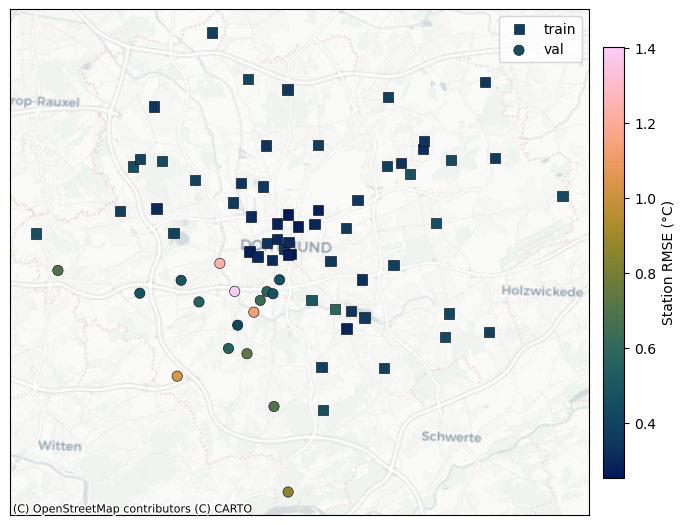

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [24]:
# 2. map: reuse all_stations, add coords, rename to what obs_map expects
coords = df.groupby("station_id")[["latitude", "longitude"]].first().reset_index()
stn = all_stations.merge(coords, on="station_id")
stn = stn.rename(columns={"model_rmse": "rmse"})

obs_map(stn, "rmse")

In [12]:

# predict on ALL data (build a DMatrix from the full feature set)
features = list(X_train.columns)                    # whatever columns the model was trained on
dall = xgb.DMatrix(df[features], feature_names=features)
pred_resid_xgb = model.predict(dall)             # residual predictions (if trained on temp_diff)

df_eval = df.copy()
df_eval["pred_temp"] = pred_resid_xgb + df["t2m_corr"].values   # XGB reconstructed
df_eval["era5_temp"] = df["t2m_corr"].values                     # ERA5 baseline
obs = df["air_temperature"].values


per_station = (df_eval.assign(obs=obs)
    .groupby("station_id")
    .apply(lambda g: pd.Series({
        "xgb_rmse":  np.sqrt(mean_squared_error(g["obs"], g["pred_temp"])),
        "era5_rmse": np.sqrt(mean_squared_error(g["obs"], g["era5_temp"])),
    }))
    .reset_index())
per_station["improvement"] = per_station["era5_rmse"] - per_station["xgb_rmse"]
print(per_station.sort_values("improvement", ascending=False).round(3))

   station_id  xgb_rmse  era5_rmse  improvement
8      DOBHAP     0.706      4.197        3.491
1      DOBBRS     0.358      2.193        1.835
9      DOBHBF     0.338      1.909        1.571
0      DOBBHS     0.335      1.897        1.562
22     DODFRP     0.295      1.778        1.483
..        ...       ...        ...          ...
54     DOTLST     0.524      1.326        0.802
28     DOTADR     0.795      1.577        0.782
15     DOBPSW     0.756      1.444        0.688
35     DOTAWS     0.951      1.583        0.633
56     DOTOFH     0.816      1.267        0.451

[76 rows x 4 columns]


/scratch/local/12012288/ipykernel_1214330/2982823930.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


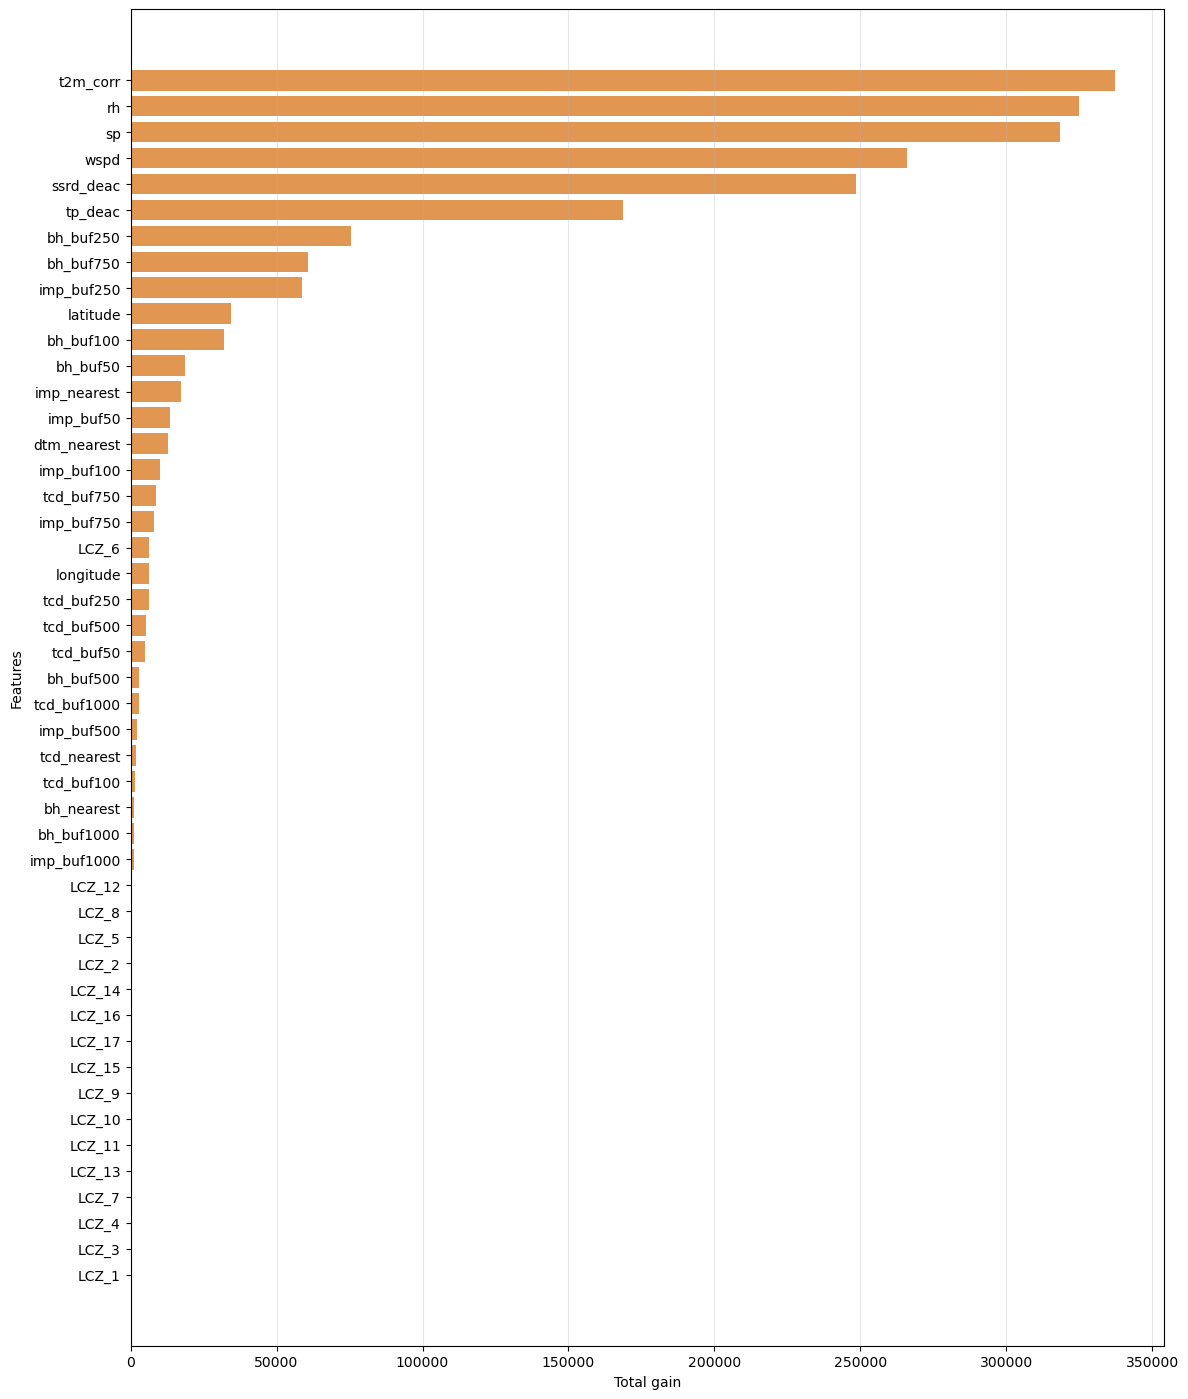


Feature importances (sorted):
t2m_corr: 337078.687500
rh: 325011.843750
sp: 318314.218750
wspd: 266107.687500
ssrd_deac: 248528.203125
tp_deac: 168543.000000
bh_buf250: 75607.437500
bh_buf750: 60596.171875
imp_buf250: 58858.367188
latitude: 34274.171875
bh_buf100: 31978.525391
bh_buf50: 18675.091797
imp_nearest: 17132.558594
imp_buf50: 13420.307617
dtm_nearest: 12855.670898
imp_buf100: 10225.613281
tcd_buf750: 8820.415039
imp_buf750: 7875.778320
LCZ_6: 6254.211914
longitude: 6252.617676
tcd_buf250: 6226.125977
tcd_buf500: 5150.438477
tcd_buf50: 4918.980469
bh_buf500: 2924.381592
tcd_buf1000: 2799.178711
imp_buf500: 2048.913818
tcd_nearest: 1887.708618
tcd_buf100: 1371.355835
bh_nearest: 1085.171875
bh_buf1000: 1075.521729
imp_buf1000: 1055.923828
LCZ_12: 135.073395
LCZ_8: 110.196342
LCZ_5: 34.207008
LCZ_2: 17.551802
LCZ_14: 16.572702
LCZ_16: 0.000000
LCZ_17: 0.000000
LCZ_15: 0.000000
LCZ_9: 0.000000
LCZ_10: 0.000000
LCZ_11: 0.000000
LCZ_13: 0.000000
LCZ_7: 0.000000
LCZ_4: 0.000000
LCZ

In [9]:
import cmcrameri.cm as cmc

def importance(model):
    # For models trained with xgb.train() and DMatrix with feature_names
    feature_names = model.feature_names
    cmap = cmc.batlow
    # sample two colors away from extremes for clarity
    predicted_color = cmap(0.7)
        # Get importance scores (you can choose different types)
    importance_dict = model.get_score(importance_type='total_gain')  # or 'gain', 'cover'
    
    # Convert to arrays, ensuring order matches feature_names
    importances = np.array([importance_dict.get(fname, 0.0) for fname in feature_names])

    sorted_indices = np.argsort(importances)
    sorted_importances = importances[sorted_indices]
    sorted_features = [feature_names[i] for i in sorted_indices]

    # Create the horizontal bar plot
    plt.figure(figsize=(12, max(8, len(sorted_features) * 0.3)))
    bars = plt.barh(range(len(sorted_features)), sorted_importances, 
                    color=predicted_color,
                    #  alpha=0.7
                    )

    # Customize the plot
    plt.yticks(range(len(sorted_features)), sorted_features)
    plt.xlabel('Total gain')
    plt.ylabel('Features')
    # plt.title('XGBoost Feature Importances')
    plt.grid(axis='x', alpha=0.3)

        # # Add value labels on bars
        # for i, (bar, v) in enumerate(zip(bars, sorted_importances)):
        #     plt.text(v + max(sorted_importances) * 0.01, i, f'{v:.3f}', 
        #             va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nFeature importances (sorted):")
    for feat, val in zip(sorted_features[::-1], sorted_importances[::-1]):
        print(f"{feat}: {val:.6f}")
    
importance(model)

## Land Use Regression

## Scaling ?


In [30]:
def select_predictors_full(X_tr, y_tr, X_val, y_val, geo_candidates, t2m_corr_val):
    selected = []
    score = lambda cols: val_r2_recon(X_tr, y_tr, X_val, y_val, cols, t2m_corr_val)

    def try_group(options):
        nonlocal selected
        base = score(selected)
        best_opt, best_s = None, base
        for opt in options:
            if opt and not all(c in X_tr.columns for c in opt):
                continue
            s = score(selected + opt)
            if s > best_s:
                best_opt, best_s = opt, s
        if best_opt:
            selected += best_opt

    # cyclical time: both-or-neither, each cycle its own group
    try_group([["tod_sin", "tod_cos"], []])
    try_group([["doy_sin", "doy_cos"], []])

    # met groups
    try_group([["t2m"], ["t2m_corr"]])
    try_group([["d2m"], ["rh"]])
    try_group([["u10", "v10"], ["wspd"]])

    # lat/lon
    try_group([["latitude", "longitude"], []])

    # geo families
    fams = {}
    for c in geo_candidates:
        fams.setdefault(c.split("_")[0], []).append(c)
    for members in fams.values():
        try_group([[m] for m in members])

    return selected, score(selected)

In [31]:
# candidates: geo only (tod/doy handled by their groups, not as geo)
met_cols = {"t2m", "t2m_corr", "d2m", "rh", "u10", "v10", "wspd"}
exclude  = {"station_id", "datetime_utc", "air_temperature", "temp_diff", "lcz_nearest"}
geo_candidates = [c for c in df.columns
                  if c not in exclude and c not in met_cols
                  and c not in ("latitude", "longitude")
                  and not c.startswith(("LCZ_", "tod_", "doy_"))]

SCALE = True
X = df.drop(columns=["temp_diff"])
y = df["temp_diff"]
X_tr, X_val, y_tr, y_val = split_data(X, y, mode="block_spatial", quadrant="ne")

if SCALE:
    scale_cols = [c for c in geo_candidates if c in X_tr.columns] + \
                 [c for c in met_cols if c in X_tr.columns] + \
                 ["tod_sin", "tod_cos", "doy_sin", "doy_cos"]
    scale_cols = [c for c in scale_cols if c in X_tr.columns]
    X_tr, X_val, _ = scale_train_val(X_tr, X_val, scale_cols)

t2m_corr_val = df.loc[y_val.index, "t2m_corr"]      # UNSCALED for reconstruction

sel, r2 = select_predictors_full(X_tr, y_tr, X_val, y_val, geo_candidates, t2m_corr_val)
print(f"full-data (scaled={SCALE}): recon val_R²={r2:.3f}")
print("selected:", sel)

full-data (scaled=True): recon val_R²=0.968
selected: ['tod_sin', 'tod_cos', 'doy_sin', 'doy_cos', 't2m', 'u10', 'v10', 'bh_buf100', 'tcd_buf500', 'imp_buf250', 'ssrd', 'tp', 'sp']


In [25]:
Xf = df[sel].copy()
if SCALE:
    Xf[sel] = StandardScaler().fit_transform(Xf[sel])
model = sm.OLS(df["temp_diff"], sm.add_constant(Xf)).fit()
print(model.params.sort_values(key=abs, ascending=False))

const          0.568675
d2m           -0.317853
bh_buf750      0.207994
t2m_corr       0.174513
tcd_buf750    -0.142750
v10            0.130193
tp_deac       -0.063726
u10           -0.015833
imp_buf1000   -0.004413
dtype: float64


In [26]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# --- fit the final model on TRAIN, using the selected predictors ---
# (refit on train so the comparison is on the model you actually validated;
#  or fit on all data if you want the descriptive final model — see note below)
X_all = df[sel].copy()

if SCALE:
    scaler = StandardScaler().fit(X_all[sel])   # NOTE: for honest eval, fit scaler on TRAIN only
    X_all[sel] = scaler.transform(X_all[sel])

model = sm.OLS(df["temp_diff"], sm.add_constant(X_all)).fit()

# --- predict the residual for ALL rows, reconstruct absolute temp ---
pred_resid = model.predict(sm.add_constant(X_all, has_constant="add"))

df_eval = df.copy()
df_eval["pred_temp"] = pred_resid.values + df["t2m_corr"].values   # model's reconstructed temp
df_eval["era5_temp"] = df["t2m_corr"].values                        # baseline: ERA5-corrected alone
obs = df["air_temperature"].values

# --- metrics: model vs observed, and ERA5-baseline vs observed ---
def metrics(pred, obs, label):
    resid = obs - pred
    print(f"{label:20s} RMSE={np.sqrt(np.mean(resid**2)):.3f}  "
          f"bias={np.mean(pred-obs):+.3f}  "
          f"MAE={np.mean(np.abs(resid)):.3f}  "
          f"R²={r2_score(obs, pred):.3f}")

metrics(df_eval["pred_temp"].values, obs, "LUR reconstructed")
metrics(df_eval["era5_temp"].values, obs, "ERA5-corrected only")

LUR reconstructed    RMSE=1.459  bias=-0.000  MAE=1.051  R²=0.960
ERA5-corrected only  RMSE=1.614  bias=-0.569  MAE=1.200  R²=0.951


In [27]:
per_station = (df_eval.assign(obs=obs)
    .groupby("station_id")
    .apply(lambda g: pd.Series({
        "lur_rmse":  np.sqrt(mean_squared_error(g["obs"], g["pred_temp"])),
        "era5_rmse": np.sqrt(mean_squared_error(g["obs"], g["era5_temp"])),
    }))
    .reset_index())
per_station["improvement"] = per_station["era5_rmse"] - per_station["lur_rmse"]
print(per_station.sort_values("improvement", ascending=False).round(3))

   station_id  lur_rmse  era5_rmse  improvement
1      DOBBRS     1.571      2.193        0.622
9      DOBHBF     1.465      1.909        0.444
8      DOBHAP     3.754      4.197        0.442
0      DOBBHS     1.477      1.897        0.420
33     DOTAMW     1.348      1.730        0.382
..        ...       ...        ...          ...
62     DOTSCS     2.008      1.948       -0.060
31     DOTAMB     1.922      1.843       -0.079
48     DOTHSB     1.670      1.577       -0.093
21     DODBOL     2.001      1.841       -0.160
56     DOTOFH     1.453      1.267       -0.186

[76 rows x 4 columns]


/scratch/local/12012288/ipykernel_1214330/1489296403.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [28]:
def select_forward_free(X_tr, y_tr, X_val, y_val, all_candidates, t2m_corr_val,
                        threshold=0.0):
    """Unrestricted forward selection: add the single best predictor each round."""
    selected = []
    remaining = [c for c in all_candidates if c in X_tr.columns]
    score = lambda cols: val_r2_recon(X_tr, y_tr, X_val, y_val, cols, t2m_corr_val)
    current = score(selected)

    while remaining:
        best_pred, best_s = None, current
        for cand in remaining:
            s = score(selected + [cand])
            if s > best_s:
                best_pred, best_s = cand, s

        # stop if nothing improves by more than threshold
        if best_pred is None or (best_s - current) < threshold:
            break

        selected.append(best_pred)
        remaining.remove(best_pred)
        current = best_s
        print(f"added {best_pred:20s} recon_val_R²={best_s:.4f}")

    return selected, current

In [32]:
met_cols = {"t2m", "t2m_corr", "d2m", "rh", "u10", "v10", "wspd"}
exclude  = {"station_id", "datetime_utc", "air_temperature", "temp_diff", "lcz_nearest"}

all_candidates = [c for c in X_tr.columns
                  if c not in exclude
                  and not c.startswith("LCZ_")]      # keep everything else: geo, met, lat/lon, tod/doy
t2m_corr_val = df.loc[y_val.index, "t2m_corr"]

sel, r2 = select_forward_free(X_tr, y_tr, X_val, y_val, all_candidates, t2m_corr_val)
print("selected:", sel)

added imp_buf250           recon_val_R²=0.9652
added tod_sin              recon_val_R²=0.9668
added doy_sin              recon_val_R²=0.9672
added v10                  recon_val_R²=0.9677
added ssrd                 recon_val_R²=0.9680
added tp                   recon_val_R²=0.9682
added rh                   recon_val_R²=0.9683
added doy_cos              recon_val_R²=0.9684
added bh_buf100            recon_val_R²=0.9684
added tcd_buf250           recon_val_R²=0.9685
added imp_nearest          recon_val_R²=0.9685
added tcd_buf100           recon_val_R²=0.9685
added bh_buf50             recon_val_R²=0.9685
added tcd_buf1000          recon_val_R²=0.9685
added bh_nearest           recon_val_R²=0.9685
selected: ['imp_buf250', 'tod_sin', 'doy_sin', 'v10', 'ssrd', 'tp', 'rh', 'doy_cos', 'bh_buf100', 'tcd_buf250', 'imp_nearest', 'tcd_buf100', 'bh_buf50', 'tcd_buf1000', 'bh_nearest']


In [33]:
Xf = df[sel].copy()
if SCALE:
    Xf[sel] = StandardScaler().fit_transform(Xf[sel])
model = sm.OLS(df["temp_diff"], sm.add_constant(Xf)).fit()
print(model.params.sort_values(key=abs, ascending=False))

const          0.568675
ssrd           0.357488
doy_cos        0.211031
imp_buf250     0.200694
doy_sin        0.197818
v10            0.173705
tp            -0.155262
tod_sin       -0.150170
rh             0.145108
tcd_buf250    -0.140005
bh_buf100      0.127549
tcd_buf100     0.084226
imp_nearest    0.061179
bh_buf50      -0.053584
tcd_buf1000   -0.020914
bh_nearest    -0.005582
dtype: float64


In [34]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# --- fit the final model on TRAIN, using the selected predictors ---
# (refit on train so the comparison is on the model you actually validated;
#  or fit on all data if you want the descriptive final model — see note below)
X_all = df[sel].copy()

if SCALE:
    scaler = StandardScaler().fit(X_all[sel])   # NOTE: for honest eval, fit scaler on TRAIN only
    X_all[sel] = scaler.transform(X_all[sel])

model = sm.OLS(df["temp_diff"], sm.add_constant(X_all)).fit()

# --- predict the residual for ALL rows, reconstruct absolute temp ---
pred_resid = model.predict(sm.add_constant(X_all, has_constant="add"))

df_eval = df.copy()
df_eval["pred_temp"] = pred_resid.values + df["t2m_corr"].values   # model's reconstructed temp
df_eval["era5_temp"] = df["t2m_corr"].values                        # baseline: ERA5-corrected alone
obs = df["air_temperature"].values

# --- metrics: model vs observed, and ERA5-baseline vs observed ---
def metrics(pred, obs, label):
    resid = obs - pred
    print(f"{label:20s} RMSE={np.sqrt(np.mean(resid**2)):.3f}  "
          f"bias={np.mean(pred-obs):+.3f}  "
          f"MAE={np.mean(np.abs(resid)):.3f}  "
          f"R²={r2_score(obs, pred):.3f}")

metrics(df_eval["pred_temp"].values, obs, "LUR reconstructed")
metrics(df_eval["era5_temp"].values, obs, "ERA5-corrected only")

LUR reconstructed    RMSE=1.383  bias=+0.000  MAE=0.992  R²=0.964
ERA5-corrected only  RMSE=1.614  bias=-0.569  MAE=1.200  R²=0.951
